# Case iFood, Notebook 2: Modelagem e Simulação de Impacto

## Formulação do problema

A pergunta de negócio é: qual oferta enviar para cada cliente? Modelamos a propensão de conversão no nível (cliente, oferta recebida): um único classificador estima `P(converteu = 1)` a partir dos atributos do cliente, dos atributos da oferta e do histórico comportamental. Como a oferta é input do modelo, escoramos as 10 ofertas do portfólio para cada cliente e enviamos a de maior score.

Um modelo por oferta fragmentaria os dados e não generalizaria para ofertas novas. Uplift modeling (efeito causal do envio) seria o alvo ideal, mas o teste não tem grupo controle limpo; fica como próximo passo. Com conversão em torno de 38%, avaliamos com ROC-AUC, PR-AUC, calibração e lift por decil, métricas adequadas a bases desbalanceadas.

In [1]:
import json
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = RAIZ / "data" / "processed"

AZUL = "#2a78d6"
CINZA = "#898781"
COR_POR_TIPO = {"bogo": "#2a78d6", "discount": "#1baf7a", "informational": "#eda100"}
plt.rcParams.update({
    "figure.figsize": (9, 3.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})
pd.set_option("display.max_columns", 60)

dados = pd.read_parquet(PROCESSED / "dataset_ofertas.parquet")
snapshot = pd.read_parquet(PROCESSED / "clientes_snapshot.parquet")
print(f"{dados.shape[0]} envios | conversão geral: {dados['converteu'].mean():.2%}")

76277 envios | conversão geral: 38.31%


## 1. Features

Ficam fora: identificadores (o `id_oferta` é substituído pelos atributos da oferta, para generalizar a ofertas novas), colunas de desfecho (descrevem o que aconteceu depois do envio) e colunas constantes (`canal_email` está em todas as ofertas). O corte temporal contra vazamento já foi garantido na construção das features no notebook 1.

In [2]:
alvo = "converteu"
ids = ["id_cliente", "id_envio", "id_oferta"]
desfecho = ["visualizou", "conversao_acidental", "gasto_na_janela", "compras_na_janela", "fim_janela"]

features = [c for c in dados.columns if c not in ids + desfecho + [alvo] and dados[c].nunique(dropna=False) > 1]
categoricas = ["tipo_oferta", "genero"]
numericas = [c for c in features if c not in categoricas]
dados[categoricas] = dados[categoricas].astype("category")

print(len(features), "features:", features)

27 features: ['dia_recebimento', 'tipo_oferta', 'valor_minimo', 'duracao_dias', 'valor_desconto', 'num_canais', 'canal_web', 'canal_mobile', 'canal_social', 'num_transacoes_antes', 'gasto_total_antes', 'ticket_medio_antes', 'ofertas_recebidas_antes', 'ofertas_vistas_antes', 'ofertas_convertidas_antes', 'recebidas_mesmo_tipo_antes', 'convertidas_mesmo_tipo_antes', 'idade', 'genero', 'limite_cartao', 'cadastro_incompleto', 'tempo_cadastro_dias', 'ano_cadastro', 'recencia_ultima_compra', 'taxa_visualizacao_previa', 'taxa_conversao_previa', 'taxa_conversao_previa_mesmo_tipo']


## 2. Split treino e teste

Cada cliente aparece em até 6 envios com features altamente correlacionadas entre si. Um split aleatório por linha colocaria o mesmo cliente nos dois conjuntos e inflaria as métricas. O `StratifiedGroupKFold` separa por cliente e mantém a taxa de conversão equilibrada.

In [3]:
divisao = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
idx_treino, idx_teste = next(divisao.split(dados[features], dados[alvo], groups=dados["id_cliente"]))
treino, teste = dados.iloc[idx_treino], dados.iloc[idx_teste]

print(f"treino: {len(treino)} envios, {treino['id_cliente'].nunique()} clientes, conversão {treino[alvo].mean():.2%}")
print(f"teste: {len(teste)} envios, {teste['id_cliente'].nunique()} clientes, conversão {teste[alvo].mean():.2%}")
print("clientes em comum:", len(set(treino["id_cliente"]) & set(teste["id_cliente"])))

treino: 61024 envios, 13595 clientes, conversão 38.31%
teste: 15253 envios, 3399 clientes, conversão 38.31%
clientes em comum: 0


## 3. Baseline e modelos

O baseline é a taxa média de conversão por tipo de oferta (e por oferta individual) calculada no treino e usada como score no teste: o equivalente a priorizar o tipo que historicamente converte mais, igual para todos. Comparamos dois modelos:

- Regressão Logística: linear e auditável, com imputação por mediana, padronização e one-hot.
- LightGBM: boosting de árvores, captura interações e lida nativamente com nulos e categóricas. O early stopping usa uma fatia de validação separada por cliente dentro do treino.

In [4]:
def metricas_de(score):
    return {
        "roc_auc": roc_auc_score(teste[alvo], score),
        "pr_auc": average_precision_score(teste[alvo], score),
        "log_loss": log_loss(teste[alvo], np.clip(score, 1e-6, 1 - 1e-6)),
        "brier": brier_score_loss(teste[alvo], np.clip(score, 0, 1)),
    }


score_baseline_tipo = teste["tipo_oferta"].map(treino.groupby("tipo_oferta", observed=True)[alvo].mean()).astype(float)
score_baseline_oferta = teste["id_oferta"].map(treino.groupby("id_oferta")[alvo].mean()).astype(float)

In [5]:
logistica = Pipeline([
    ("preparacao", ColumnTransformer([
        ("numericas", Pipeline([("imputacao", SimpleImputer(strategy="median")), ("escala", StandardScaler())]), numericas),
        ("categoricas", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categoricas),
    ])),
    ("classificador", LogisticRegression(max_iter=3000, random_state=42)),
])
logistica.fit(treino[features], treino[alvo])
score_logistica = logistica.predict_proba(teste[features])[:, 1]

In [6]:
idx_ajuste, idx_validacao = next(divisao.split(treino[features], treino[alvo], groups=treino["id_cliente"]))
ajuste, validacao = treino.iloc[idx_ajuste], treino.iloc[idx_validacao]

modelo = lgb.LGBMClassifier(
    n_estimators=2000, learning_rate=0.03, num_leaves=63, min_child_samples=80,
    subsample=0.9, subsample_freq=1, colsample_bytree=0.9, reg_lambda=1.0,
    random_state=42, verbose=-1,
)
modelo.fit(
    ajuste[features], ajuste[alvo],
    eval_set=[(validacao[features], validacao[alvo])],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(100, verbose=False)],
)
score_lgbm = modelo.predict_proba(teste[features])[:, 1]
print("melhor iteração:", modelo.best_iteration_)

melhor iteração: 228


In [7]:
comparacao = pd.DataFrame({
    "baseline taxa por tipo": metricas_de(score_baseline_tipo),
    "baseline taxa por oferta": metricas_de(score_baseline_oferta),
    "regressão logística": metricas_de(score_logistica),
    "lightgbm": metricas_de(score_lgbm),
}).T.round(4)
comparacao

,roc_auc,pr_auc,log_loss,brier
baseline taxa por tipo,0.5214,0.3945,0.6648,0.2360
baseline taxa por oferta,0.6527,0.5098,0.6305,0.2201
regressão logística,0.7395,0.6197,0.5778,0.1976
lightgbm,0.8010,0.6979,0.5213,0.1750


O LightGBM vence em todas as métricas, com a logística no meio do caminho: há não linearidades e interações reais que a forma linear não captura. Os baselines mostram que o tipo da oferta sozinho separa pouco; o ganho vem de cruzar oferta com comportamento do cliente. O LightGBM é o modelo final.

## 4. Avaliação do modelo final

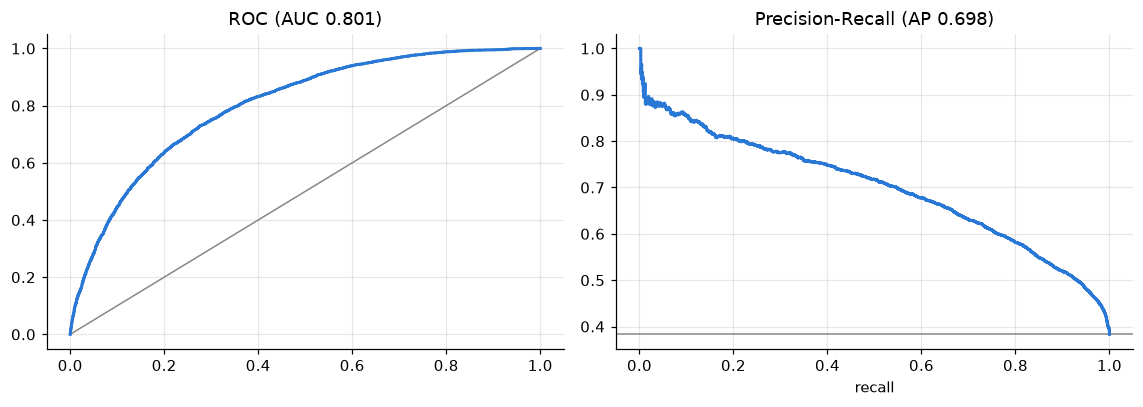

In [8]:
fpr, tpr, _ = roc_curve(teste[alvo], score_lgbm)
precisao, recall, _ = precision_recall_curve(teste[alvo], score_lgbm)
taxa_teste = teste[alvo].mean()

fig, eixos = plt.subplots(1, 2, figsize=(10.5, 3.8))
eixos[0].plot([0, 1], [0, 1], color=CINZA, linewidth=1)
eixos[0].plot(fpr, tpr, color=AZUL, linewidth=2)
eixos[0].set_title(f"ROC (AUC {roc_auc_score(teste[alvo], score_lgbm):.3f})")
eixos[1].axhline(taxa_teste, color=CINZA, linewidth=1)
eixos[1].plot(recall, precisao, color=AZUL, linewidth=2)
eixos[1].set_title(f"Precision-Recall (AP {average_precision_score(teste[alvo], score_lgbm):.3f})")
eixos[1].set_xlabel("recall")
fig.tight_layout()
plt.show()

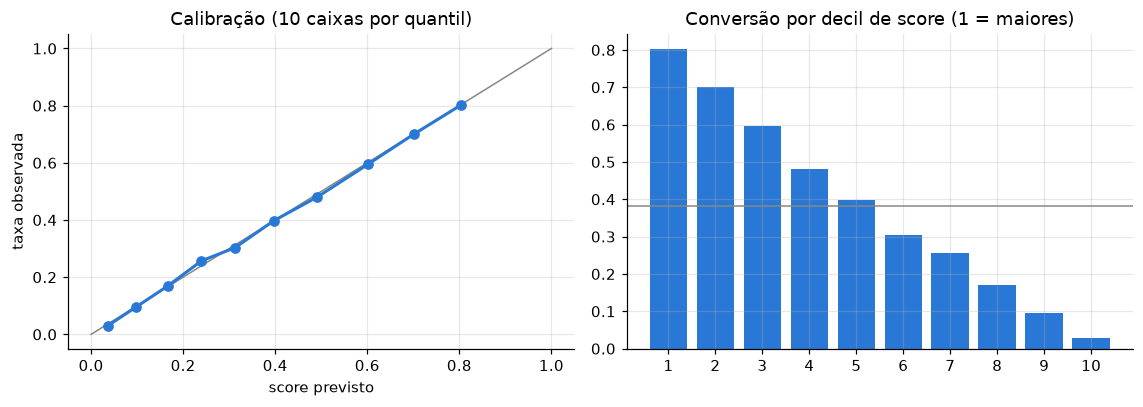

limiar 0,5: precisão 0.678 | recall 0.602


,decil,envios,conversoes,taxa_conversao,score_medio,lift,ganho_acumulado
0,1,1526,1224,0.802,0.804,2.094,0.209
1,2,1525,1068,0.700,0.701,1.828,0.392
2,3,1525,908,0.595,0.602,1.554,0.548
3,4,1525,733,0.481,0.492,1.255,0.673
4,5,1526,606,0.397,0.397,1.037,0.777
5,6,1525,463,0.304,0.313,0.793,0.856
6,7,1525,392,0.257,0.240,0.671,0.923
7,8,1525,258,0.169,0.166,0.442,0.967
8,9,1525,146,0.096,0.098,0.250,0.992
9,10,1526,45,0.029,0.036,0.077,1.000


In [9]:
score_caixa, taxa_caixa = calibration_curve(teste[alvo], score_lgbm, n_bins=10, strategy="quantile")[::-1]

avaliacao = pd.DataFrame({"alvo": teste[alvo].values, "score": score_lgbm})
avaliacao["decil"] = pd.qcut(avaliacao["score"].rank(method="first", ascending=False), 10, labels=range(1, 11))
lift = (
    avaliacao.groupby("decil", observed=True)
    .agg(envios=("alvo", "size"), conversoes=("alvo", "sum"), taxa_conversao=("alvo", "mean"), score_medio=("score", "mean"))
    .reset_index()
)
lift["lift"] = lift["taxa_conversao"] / taxa_teste
lift["ganho_acumulado"] = lift["conversoes"].cumsum() / lift["conversoes"].sum()

fig, eixos = plt.subplots(1, 2, figsize=(10.5, 3.8))
eixos[0].plot([0, 1], [0, 1], color=CINZA, linewidth=1)
eixos[0].plot(score_caixa, taxa_caixa, color=AZUL, linewidth=2, marker="o")
eixos[0].set_title("Calibração (10 caixas por quantil)")
eixos[0].set_xlabel("score previsto")
eixos[0].set_ylabel("taxa observada")
eixos[1].bar(lift["decil"].astype(str), lift["taxa_conversao"], color=AZUL)
eixos[1].axhline(taxa_teste, color=CINZA, linewidth=1)
eixos[1].set_title("Conversão por decil de score (1 = maiores)")
fig.tight_layout()
plt.show()

previsao = (score_lgbm >= 0.5).astype(int)
print(f"limiar 0,5: precisão {precision_score(teste[alvo], previsao):.3f} | recall {recall_score(teste[alvo], previsao):.3f}")
lift.round(3)

A calibração acompanha a diagonal, então o score pode ser lido como probabilidade real de conversão, o que sustenta a simulação de negócio adiante. A ordenação é forte: o primeiro decil converte 80% (lift 2,1) e o último 3%. A política de envio usa ranking, não corte fixo, mas registramos acima a referência de operação com limiar 0,5.

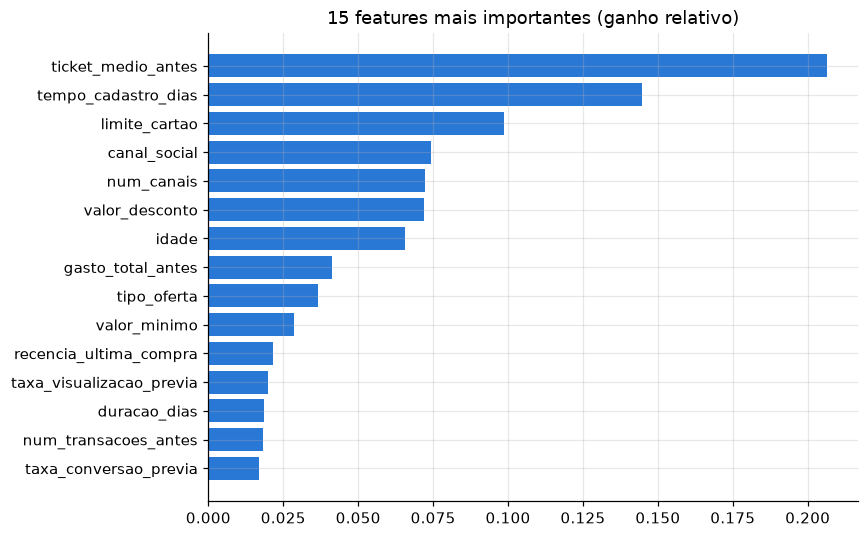

In [10]:
importancias = (
    pd.DataFrame({"feature": modelo.booster_.feature_name(), "importancia": modelo.booster_.feature_importance("gain")})
    .assign(importancia_relativa=lambda df: df["importancia"] / df["importancia"].sum())
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

top15 = importancias.head(15).iloc[::-1]
plt.figure(figsize=(8, 5))
plt.barh(top15["feature"], top15["importancia_relativa"], color=AZUL)
plt.title("15 features mais importantes (ganho relativo)")
plt.tight_layout()
plt.show()

Leitura de negócio:

- O ticket médio pré-envio é o preditor número 1 (22% do ganho): o gasto habitual define quais gastos mínimos são atingíveis sem mudar o comportamento do cliente.
- Maturidade e poder de compra (`tempo_cadastro_dias`, `limite_cartao`, `idade`) vêm em seguida e servem de proxy quando o histórico é curto.
- Os atributos da oferta somam cerca de 30% do ganho (`valor_desconto`, `num_canais`, `canal_social`, `tipo_oferta`, `valor_minimo`). É o que permite ranquear ofertas diferentes para o mesmo cliente. O destaque de `canal_social` é coerente com a maior taxa de visualização vista na EDA.
- O histórico com ofertas anteriores pesa menos que o esperado, em parte porque metade dos envios ocorre nas primeiras ondas, quando esse histórico é raso.

## 5. Simulação de impacto de negócio

Comparamos duas políticas nos clientes do teste (nunca vistos no treino):

- Política aleatória: a observada no experimento; a taxa e a receita do teste são o desempenho real dela.
- Política do modelo: escora as 10 ofertas por cliente (usando o snapshot de comportamento) e envia a de maior score, sem preferir informacional em empate.

Como o modelo é calibrado, a conversão esperada da política é a média dos scores escolhidos. A receita líquida esperada por envio é `score x (gasto médio por conversão da oferta - desconto)`, com o gasto médio estimado no treino. Também calculamos a política que maximiza receita, pois a escolha economicamente ótima pode diferir da que maximiza conversão.

In [11]:
colunas_oferta = ["id_oferta", "tipo_oferta", "valor_minimo", "duracao_dias", "valor_desconto",
                  "num_canais", "canal_web", "canal_email", "canal_mobile", "canal_social"]
portfolio = dados[colunas_oferta].drop_duplicates().reset_index(drop=True)

economia = portfolio.merge(
    treino[treino[alvo] == 1].groupby("id_oferta")["gasto_na_janela"].mean().rename("gasto_por_conversao"),
    on="id_oferta",
)
economia["margem_por_conversao"] = economia["gasto_por_conversao"] - np.where(
    economia["tipo_oferta"] == "informational", 0.0, economia["valor_desconto"].astype(float)
)
economia[["id_oferta", "tipo_oferta", "valor_minimo", "valor_desconto", "gasto_por_conversao", "margem_por_conversao"]].round(2)

,id_oferta,tipo_oferta,valor_minimo,valor_desconto,gasto_por_conversao,margem_por_conversao
0,fafdcd668e3743c1bb461111dcafc2a4,discount,10,2,64.80,62.80
1,4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,10,10,50.98,40.98
2,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,7,3,46.31,43.31
3,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5,5,41.65,36.65
4,5a8bc65990b245e5a138643cd4eb9837,informational,0,0,21.59,21.59
5,3f207df678b143eea3cee63160fa8bed,informational,0,0,29.01,29.01
6,ae264e3637204a6fb9bb56bc8210ddfd,bogo,10,10,59.28,49.28
7,2906b810c7d4411798c6938adc9daaa5,discount,10,2,52.42,50.42
8,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,20,5,73.94,68.94
9,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,5,5,47.82,42.82


In [12]:
grade = snapshot.merge(portfolio, how="cross")
for tipo in ["bogo", "discount", "informational"]:
    marca = grade["tipo_oferta"] == tipo
    grade.loc[marca, "recebidas_mesmo_tipo_antes"] = grade.loc[marca, f"recebidas_{tipo}"]
    grade.loc[marca, "convertidas_mesmo_tipo_antes"] = grade.loc[marca, f"convertidas_{tipo}"]
grade["taxa_conversao_previa_mesmo_tipo"] = np.where(
    grade["recebidas_mesmo_tipo_antes"] > 0,
    grade["convertidas_mesmo_tipo_antes"] / grade["recebidas_mesmo_tipo_antes"], 0.0,
)
grade["dia_recebimento"] = 24.0
for coluna in categoricas:
    grade[coluna] = grade[coluna].astype(pd.CategoricalDtype(categories=dados[coluna].cat.categories))

grade["score"] = modelo.predict_proba(grade[features])[:, 1]
grade = grade.merge(economia[["id_oferta", "margem_por_conversao"]], on="id_oferta")
grade["receita_esperada"] = grade["score"] * grade["margem_por_conversao"]
grade["eh_informacional"] = (grade["tipo_oferta"] == "informational").astype(int)
print("grade:", grade["id_cliente"].nunique(), "clientes x", len(portfolio), "ofertas")

grade: 17000 clientes x 10 ofertas


In [13]:
def melhor_por_cliente(criterio):
    return (
        grade.sort_values(["id_cliente", criterio, "eh_informacional"], ascending=[True, False, True])
        .groupby("id_cliente")
        .head(1)
    )


melhor_conversao = melhor_por_cliente("score")
melhor_receita = melhor_por_cliente("receita_esperada")
melhor_conversao["tipo_oferta"].value_counts()

tipo_oferta
discount         9858
informational    6847
bogo              295
Name: count, dtype: int64

In [14]:
clientes_teste = set(teste["id_cliente"])
politica_conv = melhor_conversao[melhor_conversao["id_cliente"].isin(clientes_teste)]
politica_receita = melhor_receita[melhor_receita["id_cliente"].isin(clientes_teste)]

desconto_pago = np.where((teste[alvo] == 1) & (teste["tipo_oferta"] != "informational"), teste["valor_desconto"], 0.0)
receita_aleatoria = float(np.where(teste[alvo] == 1, teste["gasto_na_janela"] - desconto_pago, 0.0).mean())
taxa_aleatoria = float(teste[alvo].mean())
taxa_modelo = float(politica_conv["score"].mean())
receita_modelo = float(politica_receita["receita_esperada"].mean())

print(f"sanidade da calibração: score médio nos envios reais {score_lgbm.mean():.4f} vs taxa observada {taxa_aleatoria:.4f}")
print(f"conversão: aleatória {taxa_aleatoria:.2%} | modelo {taxa_modelo:.2%} | uplift {taxa_modelo / taxa_aleatoria - 1:+.1%}")
print(f"receita líquida por envio: aleatória R$ {receita_aleatoria:.2f} | modelo R$ {receita_modelo:.2f} | uplift {receita_modelo / receita_aleatoria - 1:+.1%}")

sanidade da calibração: score médio nos envios reais 0.3848 vs taxa observada 0.3831
conversão: aleatória 38.31% | modelo 62.50% | uplift +63.1%
receita líquida por envio: aleatória R$ 16.42 | modelo R$ 35.37 | uplift +115.4%


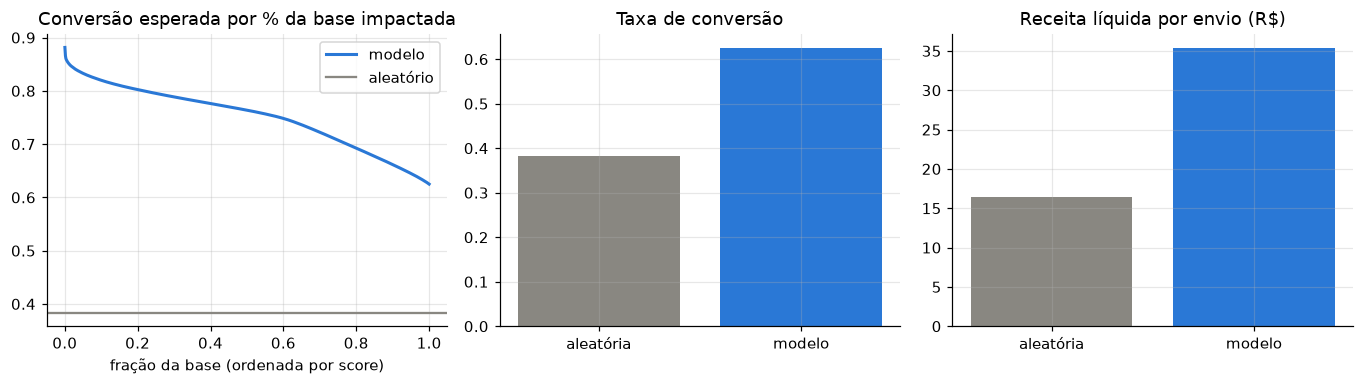

In [15]:
ordenados = politica_conv["score"].sort_values(ascending=False).reset_index(drop=True)
fracao = np.arange(1, len(ordenados) + 1) / len(ordenados)

fig, eixos = plt.subplots(1, 3, figsize=(12.5, 3.6))
eixos[0].plot(fracao, ordenados.expanding().mean(), color=AZUL, linewidth=2, label="modelo")
eixos[0].axhline(taxa_aleatoria, color=CINZA, linewidth=1.5, label="aleatório")
eixos[0].set_title("Conversão esperada por % da base impactada")
eixos[0].set_xlabel("fração da base (ordenada por score)")
eixos[0].legend()
eixos[1].bar(["aleatória", "modelo"], [taxa_aleatoria, taxa_modelo], color=[CINZA, AZUL])
eixos[1].set_title("Taxa de conversão")
eixos[2].bar(["aleatória", "modelo"], [receita_aleatoria, receita_modelo], color=[CINZA, AZUL])
eixos[2].set_title("Receita líquida por envio (R$)")
fig.tight_layout()
plt.show()

A sanidade sustenta a simulação: o score médio nos envios reais do teste coincide com a taxa observada. O ganho vem de dar a cada cliente a oferta certa, e a curva mostra que, com orçamento restrito, impactar só o topo do ranking rende taxas bem maiores (controle interativo no dashboard).

Importante: scores de propensão medem associação, não causalidade. Parte das conversões previstas aconteceria organicamente, como as conversões acidentais provam. O número que autoriza rollout é o incremento causal, medido em teste A/B.

## 6. Exportação para o dashboard

In [16]:
metricas = {
    "geral": {
        "envios_treino": len(treino), "envios_teste": len(teste),
        "clientes_treino": int(treino["id_cliente"].nunique()), "clientes_teste": int(teste["id_cliente"].nunique()),
        "taxa_conversao_teste": round(taxa_aleatoria, 4),
    },
    "modelos": {nome: {k: round(float(v), 4) for k, v in linha.items()} for nome, linha in comparacao.iterrows()},
    "modelo_final": "lightgbm",
    "simulacao": {
        "taxa_conversao_politica_aleatoria": round(taxa_aleatoria, 4),
        "taxa_conversao_politica_modelo": round(taxa_modelo, 4),
        "receita_liquida_por_envio_aleatoria": round(receita_aleatoria, 4),
        "receita_liquida_por_envio_modelo": round(receita_modelo, 4),
    },
}
(PROCESSED / "metricas_modelos.json").write_text(json.dumps(metricas, ensure_ascii=False, indent=2), encoding="utf-8")

pd.concat([
    pd.DataFrame({"curva": "roc", "x": fpr, "y": tpr}),
    pd.DataFrame({"curva": "precision_recall", "x": recall, "y": precisao}),
    pd.DataFrame({"curva": "calibracao", "x": score_caixa, "y": taxa_caixa}),
]).to_parquet(PROCESSED / "curvas_modelo.parquet", index=False)

lift.to_parquet(PROCESSED / "lift_por_decil.parquet", index=False)
importancias.to_parquet(PROCESSED / "importancia_features.parquet", index=False)
grade[["id_cliente", "id_oferta", "tipo_oferta", "valor_minimo", "valor_desconto", "duracao_dias",
       "score", "margem_por_conversao", "receita_esperada", "eh_informacional"]].to_parquet(
    PROCESSED / "scores_ofertas.parquet", index=False
)

perfil = ["id_cliente", "idade", "genero", "limite_cartao", "cadastro_incompleto", "tempo_cadastro_dias",
          "num_transacoes_antes", "gasto_total_antes", "taxa_conversao_previa"]
recomendacoes = (
    snapshot[perfil]
    .merge(
        melhor_conversao[["id_cliente", "id_oferta", "tipo_oferta", "score"]].rename(
            columns={"id_oferta": "oferta_recomendada", "tipo_oferta": "tipo_recomendado", "score": "score_conversao"}
        ),
        on="id_cliente",
    )
    .merge(
        melhor_receita[["id_cliente", "id_oferta", "tipo_oferta", "receita_esperada"]].rename(
            columns={"id_oferta": "oferta_maior_receita", "tipo_oferta": "tipo_maior_receita"}
        ),
        on="id_cliente",
    )
)
recomendacoes.to_parquet(PROCESSED / "recomendacoes.parquet", index=False)
print("exports concluídos em", PROCESSED)

exports concluídos em c:\Users\igame\OneDrive\Área de Trabalho\IFOOD-CASE\data\processed


## 7. Limitações e próximos passos

Limitações: o modelo prevê quem converte, não quem converte por causa da oferta; a grade de recomendação usa um snapshot único de comportamento; a receita usa médias por oferta do treino; a janela de 30 dias não captura sazonalidade; fadiga e frequência de contato não são modeladas.

Próximos passos:

1. Teste A/B da política contra a regra atual, com grupo controle sem envio, para medir o incremento causal.
2. Uplift modeling aproveitando a aleatorização do experimento, direcionando oferta a quem é persuadível e suprimindo envio a conversores orgânicos.
3. Otimização de portfólio com restrições (orçamento de desconto, capacidade por canal, frequência máxima) no lugar do argmax por cliente.
4. Enriquecimento de features (comportamento no app, categorias de pedido) e monitoramento de calibração e drift com retreino periódico.